In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

In [2]:
data_json_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/data_config_orthologs.json"
with open(data_json_fn, 'r') as f:
    data_config = json.load(f)

Load usage parquet files for all species and compute sites per condition

In [3]:
species_list = list(data_config.keys())  # ['human', 'mouse', 'rat']

usage_dfs = {}
for sps in species_list:
    parquet_path = os.path.expanduser(data_config[sps]["usage_parquet"])
    if not os.path.exists(parquet_path):
        print(f"Not found: {parquet_path}")
        continue
    df = pd.read_parquet(parquet_path)
    usage_dfs[sps] = df
    print(f"{sps}: {len(df):,} rows, columns: {list(df.columns)}")

print("\nSample (human):")
usage_dfs.get("human", pd.DataFrame()).head(3)


human: 66,671,282 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
mouse: 71,135,088 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rat: 69,754,030 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']

Sample (human):


,Chromosome,Position,SSE,Alpha,Beta,Label,Condition
0,1,14763,0.176,9,42,3,0
1,1,14763,0.104,14,121,3,0
2,1,14828,0.912,31,3,3,0


In [4]:

# Build a tidy DataFrame: species × condition → n_sites
# Condition labels come from data_config; usage parquet has one row per site×condition

records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    counts = df[df[cond_col].isin(known_indices)].groupby(cond_col).size().reset_index(name="n_sites")
    for _, row in counts.iterrows():
        cond_idx = int(row[cond_col])
        cond_name = idx_to_name[cond_idx]
        tissue = cond_name.rsplit("_", 1)[0] if "_" in cond_name else cond_name
        try:
            timepoint = int(cond_name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            timepoint = None
        records.append({
            "species": sps,
            "condition_idx": cond_idx,
            "condition_name": cond_name,
            "tissue": tissue,
            "timepoint": timepoint,
            "n_sites": int(row["n_sites"]),
        })

df_sites = pd.DataFrame(records)
print(f"Total rows: {len(df_sites)}")
df_sites.head(10)


Total rows: 255


,species,condition_idx,condition_name,tissue,timepoint,n_sites
0,human,0,Brain_1,Brain,1,1069490
1,human,1,Brain_10,Brain,10,927583
2,human,2,Brain_11,Brain,11,403451
3,human,3,Brain_12,Brain,12,1399528
4,human,4,Brain_13,Brain,13,1542221
5,human,5,Brain_14,Brain,14,2147288
6,human,6,Brain_15,Brain,15,367808
7,human,7,Brain_2,Brain,2,807913
8,human,8,Brain_3,Brain,3,645852
9,human,9,Brain_4,Brain,4,216729


In [ ]:
# Diagnose: which condition indices in the parquet are NOT in data_config?
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    known_indices = set(cond_labels.values())

    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        continue

    parquet_indices = set(df[cond_col].unique())
    unknown = sorted(parquet_indices - known_indices)
    print(f"{sps}: {len(parquet_indices)} unique condition indices in parquet, "
          f"{len(known_indices)} in data_config")
    if unknown:
        print(f"  ⚠ {len(unknown)} unmapped indices: {unknown}")
    else:
        print(f"  ✓ all indices mapped")


human: 86 unique condition indices in parquet, 86 in data_config
  ✓ all indices mapped
mouse: 93 unique condition indices in parquet, 93 in data_config
  ✓ all indices mapped
rat: 83 unique condition indices in parquet, 83 in data_config
  ⚠ 7 unmapped indices: [np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89)]


In [ ]:

# Plot: 

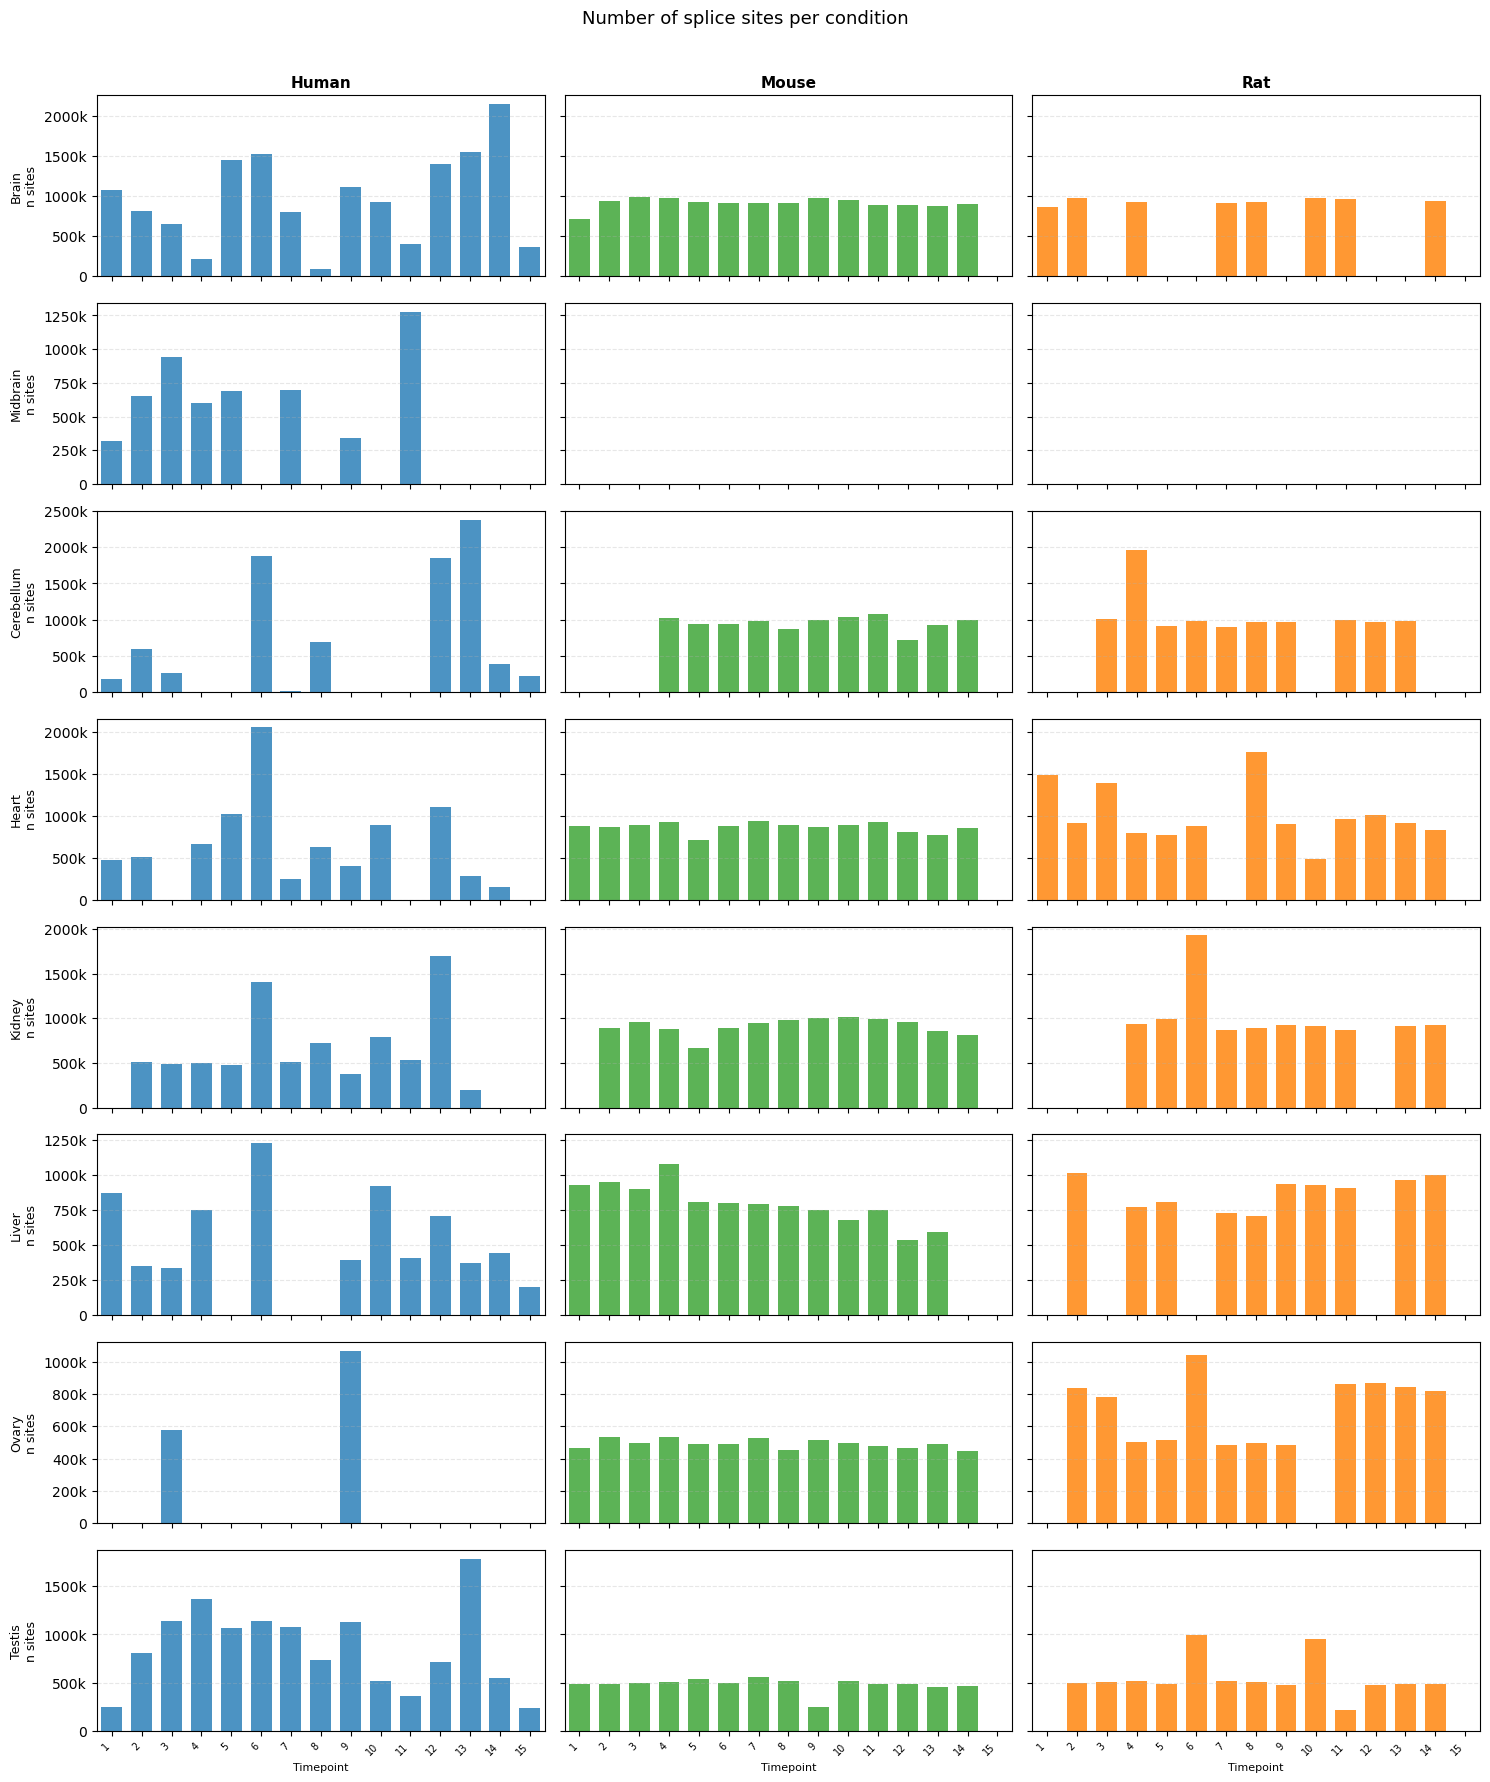

In [6]:

# Plot: n_sites per condition grouped by tissue, one column per species
# Rows = tissues, columns = species; x-axis = timepoint
# Fixed timepoints (global union across all tissues & species); unobserved → 0

TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]
SPECIES_COLORS = {"human": "#1f78b4", "mouse": "#33a02c", "rat": "#ff7f00"}

present_tissues = df_sites["tissue"].unique()
tissues = [t for t in TISSUE_ORDER if t in present_tissues]
species_list_plot = [s for s in ["human", "mouse", "rat"] if s in df_sites["species"].unique()]

# Global union of timepoints across all tissues and species
all_tps = sorted(df_sites["timepoint"].dropna().astype(int).unique())

n_tissues = len(tissues)
n_species = len(species_list_plot)

fig, axes = plt.subplots(n_tissues, n_species,
                         figsize=(n_species * 5, n_tissues * 2.2),
                         squeeze=False, sharey="row", sharex=True)

for r, tissue in enumerate(tissues):
    for c, sps in enumerate(species_list_plot):
        ax = axes[r, c]
        sub = df_sites[(df_sites["tissue"] == tissue) & (df_sites["species"] == sps)]

        tp_to_n = dict(zip(sub["timepoint"].astype("Int64"), sub["n_sites"])) if not sub.empty else {}
        heights = [tp_to_n.get(tp, 0) for tp in all_tps]

        ax.bar(range(len(all_tps)), heights, color=SPECIES_COLORS[sps], alpha=0.8, width=0.7)
        ax.set_xlim(-0.5, len(all_tps) - 0.5)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x)))
        )

        if r == 0:
            ax.set_title(sps.capitalize(), fontsize=11, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{tissue}\nn sites", fontsize=9)
        if r == n_tissues - 1:
            ax.set_xticks(range(len(all_tps)))
            ax.set_xticklabels([str(tp) for tp in all_tps], rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Timepoint", fontsize=8)

fig.suptitle("Number of splice sites per condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
